# Classification des demandes au service client

Classification automatique de réclamations rédigées en langage naturel vers **une seule
catégorie** (mono-label).

- **Données :** 300 000 réclamations de consommateurs, texte anonymisé, 21 catégories.
- **Contrainte :** toutes les catégories doivent être représentées par le modèle, aucune
  écartée.
- **Métrique :** Weighted F1 Score > 75 %, soit la moyenne des F1 par classe pondérée par la
  fréquence de chaque classe : $F_1 = \sum_i \alpha_i \cdot F_{1,i}$ avec $\alpha_i = n_i / n$.
- **Preuve attendue :** la matrice de confusion, fournie à côté du score.

Démarche : TF-IDF, puis réseau de neurones dense à `C` sorties softmax. Le modèle est entraîné
**deux fois** — d'abord sur les 21 catégories d'origine, puis sur 11 catégories regroupées, le
regroupement étant justifié par la matrice de confusion du premier modèle (section 6).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

import numpy as np
import seaborn as sns
from sklearn.metrics import f1_score, confusion_matrix, classification_report

tf.keras.utils.set_random_seed(42)

I0000 00:00:1789474390.304480    3895 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789474390.305411    3895 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789474390.816330    3895 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1789474392.560084    3895 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789474392.560561    3895 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 1. Analyse exploratoire

Objectif : connaître le volume par catégorie ($n_i$, nécessaire au calcul du F1 pondéré), puis
repérer ce qui devra être nettoyé — valeurs manquantes, doublons, artefacts d'anonymisation.

Deux écarts avec l'énoncé, à noter avant de lire la suite : le texte est **en anglais** et les
catégories sont des **produits financiers**, non des catégories d'assurance en français. La
méthode reste identique ; seuls les mots vides changent.

In [2]:
df = pd.read_csv("data/complaints.csv", nrows=1000)
print(df.shape)
print(df.columns.tolist())
df.head()

(1000, 2)
['Product', 'Consumer complaint narrative']


,Product,Consumer complaint narrative
0,Credit reporting or other personal consumer re...,"Despite multiple written requests, the unverif..."
1,Checking or savings account,My checking account has been open with Bank of...
2,Vehicle loan or lease,"Hello, My name is XXXX XXXX I am in a 72 month..."
3,Debt collection,In XXXX I purchased a XXXX XXXX from Exter fin...
4,"Credit reporting, credit repair services, or o...",Complaint : ( XXXX ) account # XXXXhas violate...


In [3]:
labels = pd.read_csv("data/complaints.csv", usecols=["Product"])
print(len(labels))
labels["Product"].value_counts().to_frame()

300000


,count
Product,
"Credit reporting, credit repair services, or other personal consumer reports",119057
Credit reporting or other personal consumer reports,55400
Debt collection,39443
Mortgage,17483
Credit card or prepaid card,15996
Checking or savings account,14930
Credit card,7510
Student loan,6570
"Money transfer, virtual currency, or money service",6213


In [4]:
df = pd.read_csv("data/complaints.csv")
print(df.isna().sum().to_frame())

                              0
Product                       0
Consumer complaint narrative  0


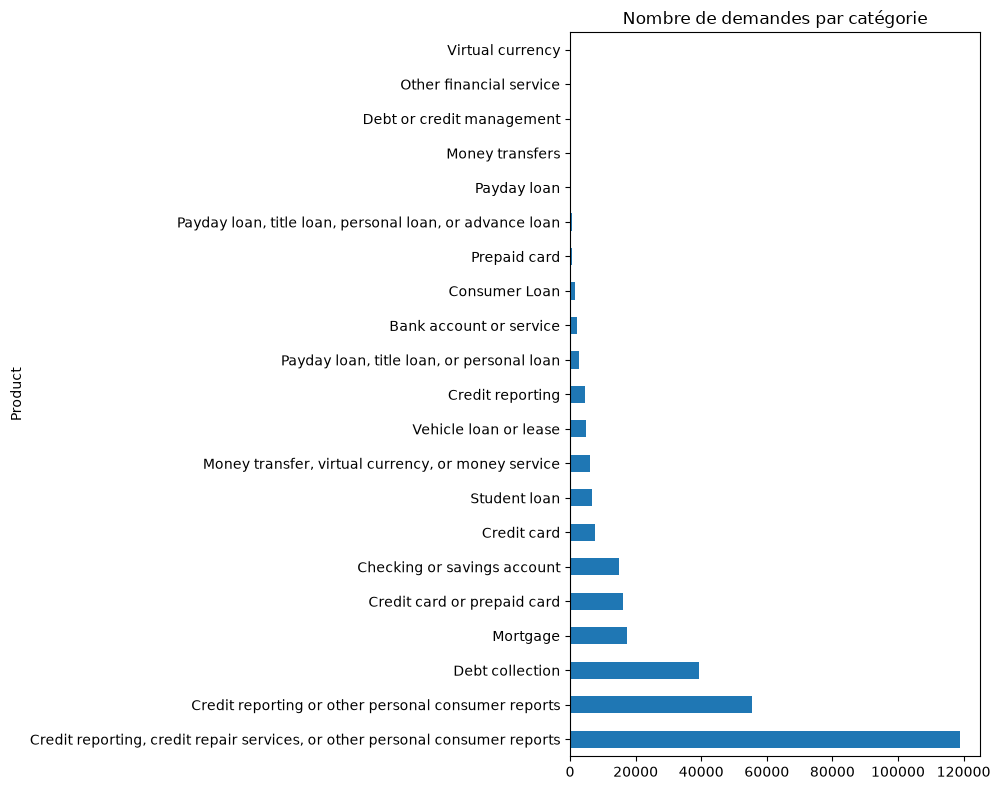

In [5]:
df["Product"].value_counts().plot(kind="barh", figsize=(10, 8))
plt.title("Nombre de demandes par catégorie")
plt.tight_layout()
plt.show()

In [6]:
longueurs = df["Consumer complaint narrative"].str.len()
print(longueurs.describe())
print("Doublons :", df.duplicated().sum())

count    300000.000000
mean       1015.808033
std        1318.016849
min           9.000000
25%         343.000000
50%         661.000000
75%        1197.000000
max       32661.000000
Name: Consumer complaint narrative, dtype: float64


Doublons : 39644


## 2. Prétraitement

Deux opérations, dans cet ordre :

1. **Suppression des doublons exacts** — 39 644 lignes, soit 13 % du jeu. Les conserver
   reviendrait à laisser les mêmes textes dans l'entraînement et dans le test, donc à
   surestimer le score. Il reste 260 356 observations.
2. **Retrait des masques d'anonymisation** — noms, dates et numéros de compte sont remplacés
   par des suites de `X` (`XXXX`, `XX/XX/XXXX`). Ils sont remplacés par une **espace** et non
   par la chaîne vide : le masque est parfois collé au mot suivant
   (`account # XXXXhas violated`), ce qui fabriquerait des mots inexistants dans le vocabulaire.

In [7]:
df = df.drop_duplicates()

In [8]:
df["texte"] = (
    df["Consumer complaint narrative"]
    .str.replace(r"X{2,}", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

print(len(df))
df[["Product", "texte"]].head()

260356


,Product,texte
0,Credit reporting or other personal consumer re...,"Despite multiple written requests, the unverif..."
1,Checking or savings account,My checking account has been open with Bank of...
2,Vehicle loan or lease,"Hello, My name is I am in a 72 month contract ..."
3,Debt collection,In I purchased a from Exter finance and receiv...
4,"Credit reporting, credit repair services, or o...",Complaint : ( ) account # has violated 15 U.S....


In [9]:
df["Product"].value_counts().to_frame()

,count
Product,
"Credit reporting, credit repair services, or other personal consumer reports",101265
Credit reporting or other personal consumer reports,37433
Debt collection,36998
Mortgage,17477
Credit card or prepaid card,15479
Checking or savings account,14928
Credit card,6762
Student loan,6559
"Money transfer, virtual currency, or money service",6173


## 3. Vectorisation

**La séparation entraînement/test vient avant la vectorisation, pas après.** Le vectoriseur
apprend un vocabulaire et des poids IDF : les ajuster sur l'ensemble des données ferait entrer
dans le modèle une information issue du test (fuite de données), et le score mesuré serait
optimiste. D'où l'ordre : `train_test_split`, puis `fit_transform` sur l'entraînement, puis
`transform` seul sur le test.

Le split est **stratifié** sur la catégorie, pour que chaque classe garde la même proportion
dans les deux jeux.

⚠️ La stratification atteint ici sa limite : la sortie affiche **21 catégories dans
l'entraînement mais 20 dans le test**. `Virtual currency` ne compte que 2 observations, toutes
deux tombées dans l'entraînement. Cette catégorie sera donc *apprise* mais **non évaluable** —
conséquence reprise en section 5.

Paramètres du TF-IDF : 10 000 termes au maximum, termes présents dans moins de 5 documents
écartés, pondération logarithmique des occurrences (`sublinear_tf`), mots vides anglais retirés.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    df["texte"],
    df["Product"],
    test_size=0.2,
    stratify=df["Product"],
    random_state=42,
)

print(y_train.nunique(), y_test.nunique())
pd.concat([y_train.value_counts(normalize=True).rename("train"), y_test.value_counts(normalize=True).rename("test")], axis=1)

21 20


,train,test
Product,,
"Credit reporting, credit repair services, or other personal consumer reports",0.388950,0.388942
Credit reporting or other personal consumer reports,0.143775,0.143782
Debt collection,0.142104,0.142111
Mortgage,0.067129,0.067119
Credit card or prepaid card,0.059452,0.059456
Checking or savings account,0.057335,0.057344
Credit card,0.025974,0.025964
Student loan,0.025192,0.025196
"Money transfer, virtual currency, or money service",0.023708,0.023717


In [11]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    min_df=5,
    sublinear_tf=True,
    stop_words="english",
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(208284, 10000)
(52072, 10000)


In [12]:
X_train_tfidf = X_train_tfidf.astype("float32")
X_test_tfidf = X_test_tfidf.astype("float32")

In [13]:
encoder = LabelEncoder()
y_train_enc = encoder.fit_transform(y_train)
y_test_enc = encoder.transform(y_test)

print(len(encoder.classes_))

21


## 4. Modèle

Réseau dense `10 000 → 256 (ReLU) → C (softmax)`, 2 565 653 paramètres.

- **softmax + `sparse_categorical_crossentropy`** : la sortie est une distribution de
  probabilité sur les `C` catégories dont la somme vaut 1, ce qui correspond exactement à la
  contrainte mono-label — une seule catégorie par demande, celle de probabilité maximale. Le
  préfixe `sparse_` indique que les étiquettes sont des entiers (`0` à `C-1`) et non des
  vecteurs one-hot.
- **Une seule couche cachée**, et un **arrêt anticipé** sur la perte de validation. 99,8 % des
  paramètres sont sur la première couche, du seul fait des 10 000 entrées : la capacité est
  déjà surdimensionnée pour la tâche et le surapprentissage apparaît dès la deuxième époque
  (l'entraînement s'arrête de lui-même à la quatrième). Il est donc traité par arrêt anticipé
  plutôt qu'en ajoutant de la régularisation ou des couches.
- Le réglage se fait sur un **jeu de validation prélevé sur l'entraînement** (10 %), jamais
  sur le test.

La fonction `create_model` est réutilisée telle quelle en section 7, pour que les deux
entraînements ne diffèrent que par l'étiquetage.

In [14]:
def create_model(n_classes):
    model = tf.keras.Sequential([
        layers.Input(shape=(X_train_tfidf.shape[1],)),
        layers.Dense(256, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ])
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["sparse_categorical_accuracy"],
    )
    return model

create_model(len(encoder.classes_)).summary()


E0000 00:00:1789474417.221711    3895 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1789474417.222367    4034 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1789474417.249844    3895 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │     2,560,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 21)             │         5,397 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,565,653 (9.79 MB)

 Trainable params: 2,565,653 (9.79 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
early = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

model = create_model(len(encoder.classes_))

history = model.fit(
    X_train_tfidf,
    y_train_enc,
    validation_split=0.1,
    epochs=30,
    batch_size=256,
    callbacks=[early],
)

Epoch 1/30


  1/733 ━━━━━━━━━━━━━━━━━━━━ 6:59 573ms/step - loss: 3.0439 - sparse_categorical_accuracy: 0.0781

  5/733 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 2.9992 - sparse_categorical_accuracy: 0.3164  

  9/733 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 2.9507 - sparse_categorical_accuracy: 0.3424

 13/733 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 2.8939 - sparse_categorical_accuracy: 0.3537 

...

721/733 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.5961 - sparse_categorical_accuracy: 0.7885

725/733 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.5960 - sparse_categorical_accuracy: 0.7886

729/733 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.5959 - sparse_categorical_accuracy: 0.7886

733/733 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.5958 - sparse_categorical_accuracy: 0.7887

733/733 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.5958 - sparse_categorical_accuracy: 0.7887 - val_loss: 0.8129 - val_sparse_categorical_accuracy: 0.7217


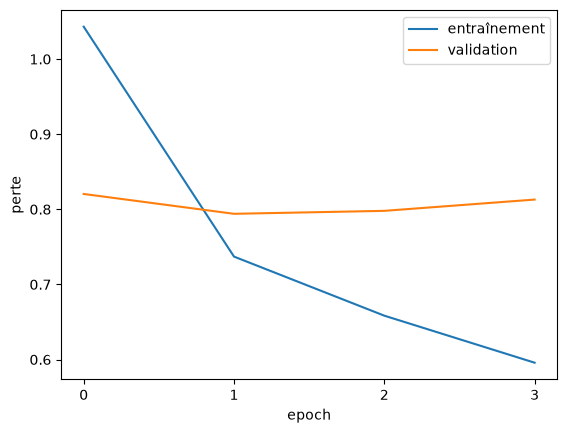

In [16]:
plt.plot(history.history["loss"], label="entraînement")
plt.plot(history.history["val_loss"], label="validation")
plt.xticks(range(len(history.history["loss"])))
plt.xlabel("epoch")
plt.ylabel("perte")
plt.legend()
plt.show()

## 5. Évaluation sur les 21 catégories d'origine

Premier entraînement, sur la nomenclature telle qu'elle est fournie, évalué sur 52 072
observations jamais vues. Le Weighted F1 atteint **70,6 %**, sous la cible de 75 %.

La matrice de confusion ci-dessous n'est pas là pour constater cet échec mais pour en chercher
la cause : c'est elle qui justifiera le regroupement de la section 6. Elle est normalisée par
ligne — chaque ligne est une vraie catégorie, chaque colonne une prédiction, et la valeur se lit
« x % des demandes de cette catégorie ont été prédites dans cette colonne ». La diagonale est
donc le rappel.

`labels=range(21)` force l'affichage des 21 catégories, y compris celles que le modèle ne
prédit jamais : sans cela, une classe abandonnée disparaîtrait silencieusement du rapport. Trois
en profitent, avec un F1 nul : `Debt or credit management` (29 observations de test),
`Other financial service` (8) et `Virtual currency`, cette dernière avec un **support de 0** —
c'est la conséquence du split vu en section 3. Son poids $\alpha_i$ dans le F1 pondéré est nul,
elle ne pèse donc pas sur le score, mais elle occupe bien un neurone de sortie et une ligne de
la matrice.

In [17]:
y_pred = np.argmax(model.predict(X_test_tfidf), axis=1)

print("Weighted F1 :", f1_score(y_test_enc, y_pred, average="weighted", zero_division=0))
print(classification_report(y_test_enc, y_pred, labels=range(21), target_names=encoder.classes_, zero_division=0))

   1/1628 ━━━━━━━━━━━━━━━━━━━━ 1:16 47ms/step

  20/1628 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step   

  39/1628 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step

  58/1628 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step

  78/1628 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step

...

1583/1628 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

1601/1628 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

1620/1628 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

1628/1628 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


Weighted F1 : 0.7055419724777019
                                                                              precision    recall  f1-score   support

                                                     Bank account or service       0.66      0.24      0.35       432
                                                 Checking or savings account       0.71      0.82      0.76      2986
                                                               Consumer Loan       0.41      0.08      0.14       278
                                                                 Credit card       0.47      0.23      0.31      1352
                                                 Credit card or prepaid card       0.60      0.68      0.64      3096
                                                            Credit reporting       0.61      0.10      0.17       922
                         Credit reporting or other personal consumer reports       0.70      0.44      0.54      7487
Credit reporting, cred

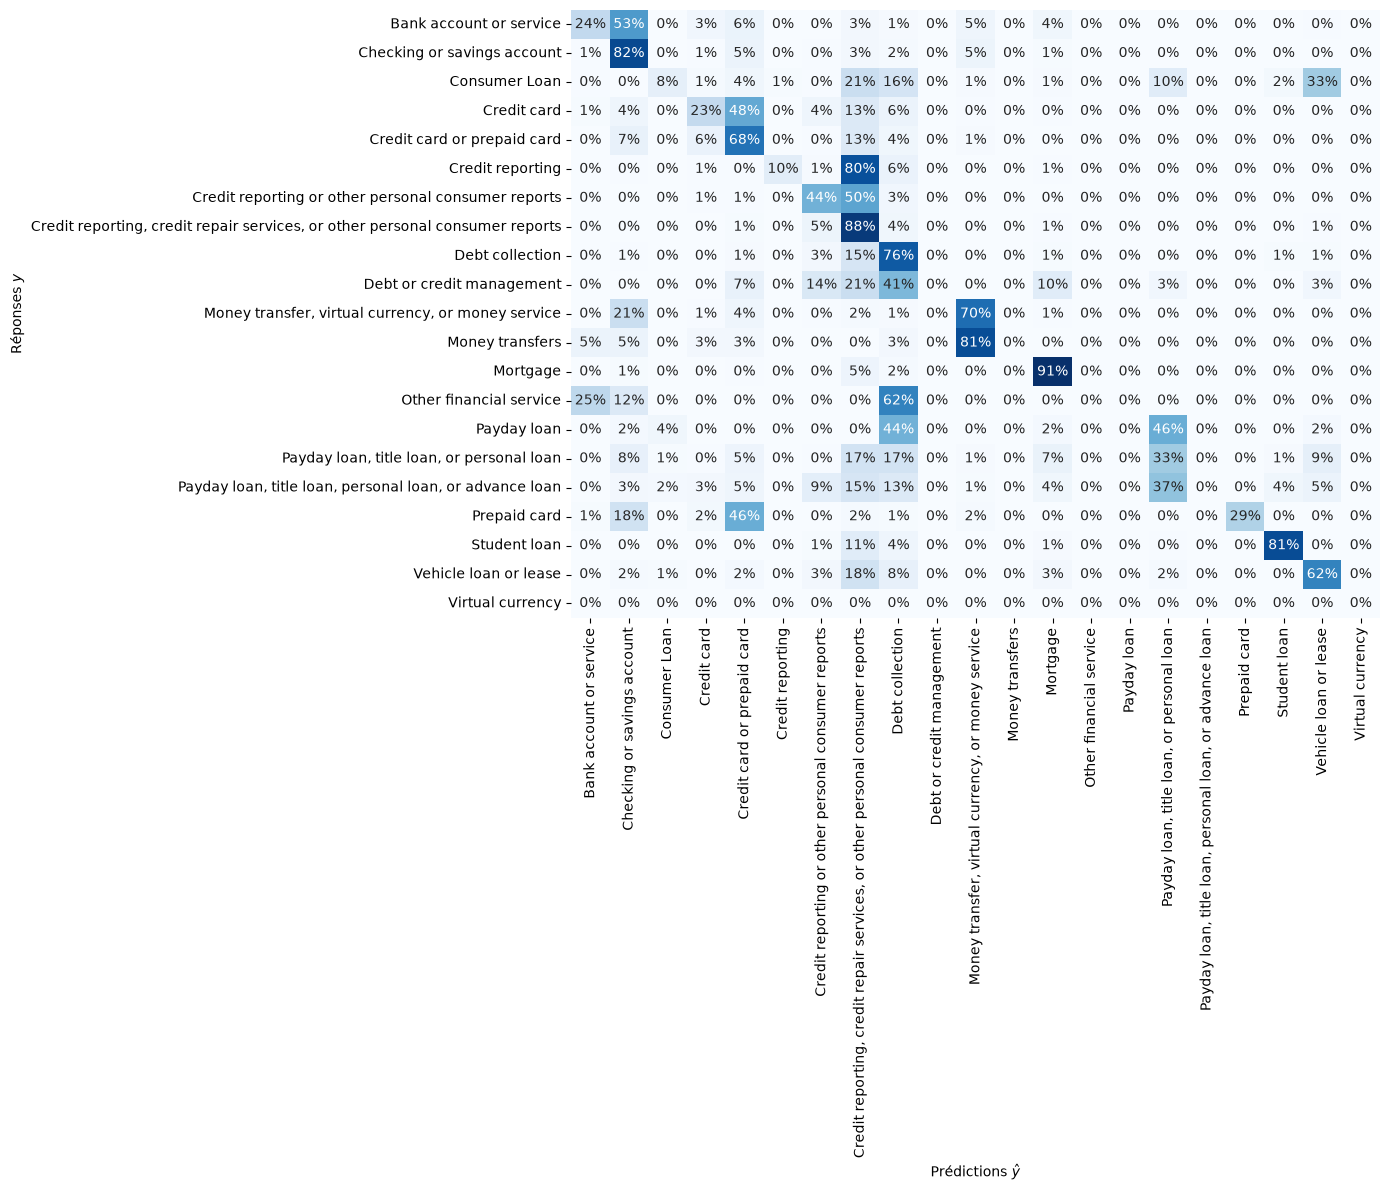

In [18]:
cm = confusion_matrix(y_test_enc, y_pred, labels=range(21), normalize="true")

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt=".0%", cmap="Blues", cbar=False, xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel("Prédictions $\\hat{y}$")
plt.ylabel("Réponses $y$")
plt.tight_layout()
plt.show()

## 6. Regroupement des libellés redondants (21 → 11)

Lecture de la matrice précédente : les erreurs ne sont pas dispersées, elles se concentrent
entre libellés qui désignent le même sujet. Les transferts les plus marqués :

| Vraie catégorie | prédite comme | part |
|---|---|---|
| `Credit reporting` | `Credit reporting, credit repair services, or other…` | 80 % |
| `Credit reporting or other personal consumer reports` | idem | 50 % |
| `Money transfers` | `Money transfer, virtual currency, or money service` | 81 % |
| `Bank account or service` | `Checking or savings account` | 53 % |
| `Credit card` | `Credit card or prepaid card` | 48 % |
| `Prepaid card` | `Credit card or prepaid card` | 46 % |
| `Payday loan` | `Payday loan, title loan, or personal loan` | 46 % |

L'explication n'est pas dans le modèle mais dans les données : la nomenclature a changé au
cours de la collecte et les anciens intitulés coexistent avec les nouveaux. Les textes sont de
même nature, seule la date de dépôt les sépare — une information absente du jeu. Aucun modèle
ne peut les distinguer.

Le mapping `FUSION` regroupe donc ces variantes, et rien d'autre. Le cas ambigu de
`Consumer Loan`, ancien intitulé fourre-tout, est tranché de la même manière : par son plus fort
transfert dans la matrice, 33 % vers `Vehicle loan or lease`. Deux résidus rares
(`Debt or credit management`, `Other financial service`) restent seuls — ils ne sont les
doublons de personne. L'`assert` vérifie que les 21 libellés sont couverts par le mapping : un
libellé oublié produirait des `NaN` silencieux dans les étiquettes.

À signaler : ce regroupement porte la classe majoritaire de 39 % à 55 % des observations, ce qui
rend mécaniquement la cible plus accessible. Il se justifie par la matrice de confusion, non par
le gain de score qu'il procure.

In [19]:
FUSION = {
    # Credit reporting — 3 libellés, 55 % des données
    "Credit reporting": "Credit reporting",
    "Credit reporting or other personal consumer reports": "Credit reporting",
    "Credit reporting, credit repair services, or other personal consumer reports": "Credit reporting",
    # Cartes — 3 libellés
    "Credit card": "Credit card or prepaid card",
    "Credit card or prepaid card": "Credit card or prepaid card",
    "Prepaid card": "Credit card or prepaid card",
    # Compte bancaire — ancien / nouveau nom
    "Bank account or service": "Checking or savings account",
    "Checking or savings account": "Checking or savings account",
    # Transfert d'argent — 3 libellés
    "Money transfer, virtual currency, or money service": "Money transfer or virtual currency",
    "Money transfers": "Money transfer or virtual currency",
    "Virtual currency": "Money transfer or virtual currency",
    # Crédit à la consommation — 3 libellés
    "Payday loan": "Payday or personal loan",
    "Payday loan, title loan, or personal loan": "Payday or personal loan",
    "Payday loan, title loan, personal loan, or advance loan": "Payday or personal loan",
    # Auto / consommation — tranché par la matrice de confusion
    "Consumer Loan": "Vehicle or consumer loan",
    "Vehicle loan or lease": "Vehicle or consumer loan",
    # Catégories autonomes, inchangées
    "Debt collection": "Debt collection",
    "Mortgage": "Mortgage",
    "Student loan": "Student loan",
    # Résidus rares, laissés seuls : ce ne sont les doublons de personne
    "Debt or credit management": "Debt or credit management",
    "Other financial service": "Other financial service",
  }

y_train_f = y_train.map(FUSION)
y_test_f = y_test.map(FUSION)

assert y_train_f.notna().all() and y_test_f.notna().all(), "libellé absent du mapping"
print(y_train_f.nunique(), y_test_f.nunique())

11 11


In [20]:
encoder_f = LabelEncoder()
y_train_f_enc = encoder_f.fit_transform(y_train_f)
y_test_f_enc = encoder_f.transform(y_test_f)

print(len(encoder_f.classes_))

11


## 7. Évaluation après regroupement

Second entraînement. Même partition, même représentation TF-IDF (`X_train_tfidf` est réutilisé
sans être recalculé), même architecture, même critère d'arrêt : **seul l'étiquetage change**.
L'écart de score est donc imputable à la nomenclature seule, et non à la modélisation.

Weighted F1 : **85,6 %**, soit 15 points de plus que sur les 21 catégories d'origine. La cible
de 75 % est atteinte.

In [21]:
early_f = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

model_f = create_model(len(encoder_f.classes_))

history_f = model_f.fit(
    X_train_tfidf,
    y_train_f_enc,
    validation_split=0.1,
    epochs=30,
    batch_size=256,
    callbacks=[early_f],
)

Epoch 1/30


  1/733 ━━━━━━━━━━━━━━━━━━━━ 5:07 420ms/step - loss: 2.3993 - sparse_categorical_accuracy: 0.0547

  5/733 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 2.3502 - sparse_categorical_accuracy: 0.4211  

  9/733 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 2.2954 - sparse_categorical_accuracy: 0.4718

 13/733 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 2.2321 - sparse_categorical_accuracy: 0.4961

...

721/733 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2956 - sparse_categorical_accuracy: 0.9022

725/733 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2956 - sparse_categorical_accuracy: 0.9022

729/733 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2956 - sparse_categorical_accuracy: 0.9022

733/733 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2956 - sparse_categorical_accuracy: 0.9022

733/733 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.2956 - sparse_categorical_accuracy: 0.9022 - val_loss: 0.4537 - val_sparse_categorical_accuracy: 0.8546


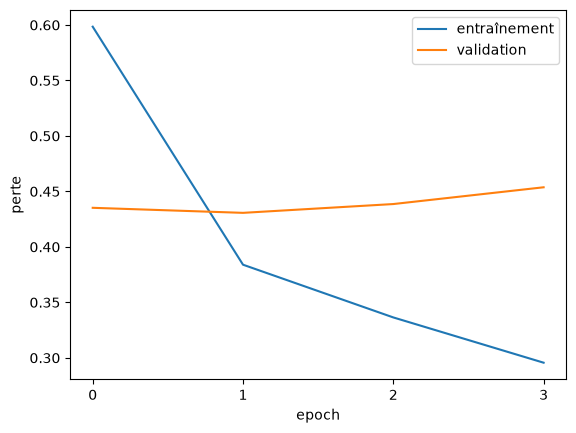

In [22]:
plt.plot(history_f.history["loss"], label="entraînement")
plt.plot(history_f.history["val_loss"], label="validation")
plt.xticks(range(len(history_f.history["loss"])))
plt.xlabel("epoch")
plt.ylabel("perte")
plt.legend()
plt.show()

In [23]:
y_pred_f = np.argmax(model_f.predict(X_test_tfidf), axis=1)

print("Weighted F1 :", f1_score(y_test_f_enc, y_pred_f, average="weighted", zero_division=0))
print(classification_report(y_test_f_enc, y_pred_f,
                            target_names=encoder_f.classes_, zero_division=0))

   1/1628 ━━━━━━━━━━━━━━━━━━━━ 1:09 43ms/step

  20/1628 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step   

  40/1628 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step

  60/1628 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step

  80/1628 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step

...

1589/1628 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

1608/1628 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

1628/1628 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

1628/1628 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


Weighted F1 : 0.8561860124089856
                                    precision    recall  f1-score   support

       Checking or savings account       0.78      0.82      0.80      3418
       Credit card or prepaid card       0.78      0.75      0.77      4576
                  Credit reporting       0.90      0.94      0.92     28662
                   Debt collection       0.79      0.74      0.76      7400
         Debt or credit management       0.00      0.00      0.00        29
Money transfer or virtual currency       0.78      0.70      0.74      1272
                          Mortgage       0.90      0.91      0.91      3495
           Other financial service       0.00      0.00      0.00         8
           Payday or personal loan       0.64      0.41      0.50       679
                      Student loan       0.90      0.81      0.86      1312
          Vehicle or consumer loan       0.67      0.61      0.64      1221

                          accuracy                   

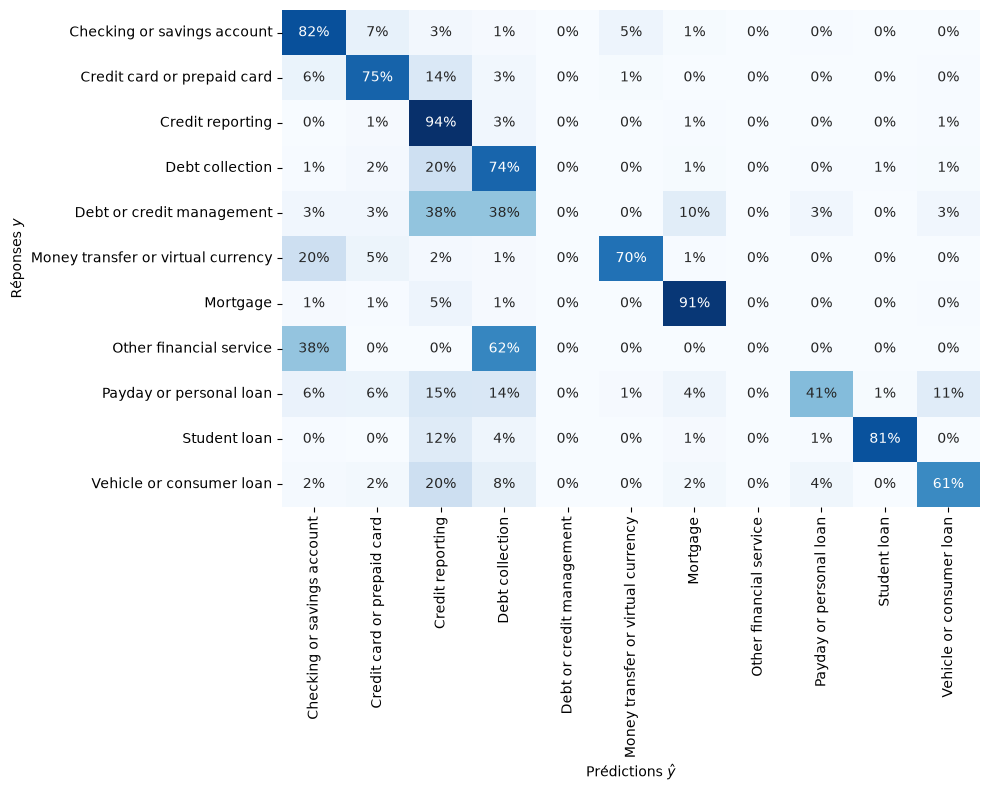

In [24]:
cm_f = confusion_matrix(y_test_f_enc, y_pred_f, normalize="true")

plt.figure(figsize=(10, 8))
sns.heatmap(cm_f, annot=True, fmt=".0%", cmap="Blues", cbar=False, xticklabels=encoder_f.classes_, yticklabels=encoder_f.classes_)
plt.xlabel("Prédictions $\\hat{y}$")
plt.ylabel("Réponses $y$")
plt.tight_layout()
plt.show()

## Conclusion

| | Weighted F1 | accuracy | macro F1 |
|---|---|---|---|
| 21 catégories d'origine | 70,6 % | 72 % | 0,40 |
| **11 catégories regroupées** | **85,6 %** | 86 % | 0,63 |
| Cible de l'énoncé | 75 % | | |

Ce que le score agrégé dissimule, et que la matrice de confusion montre :

- la moyenne **non pondérée** des F1 par classe (`macro avg`, 0,63) reste très en dessous de la
  moyenne pondérée (0,86). L'écart mesure précisément l'écart de traitement entre les grandes et
  les petites catégories ;
- `Debt or credit management` et `Other financial service` (29 et 8 observations de test) ne sont
  **jamais prédites** : leur F1 est nul. Elles restent portées par le modèle — un neurone de
  sortie leur est réservé et elles figurent dans la matrice — mais leurs effectifs sont trop
  faibles pour permettre un apprentissage. Elles pèsent 0,07 % des observations ;
- le déséquilibre n'a volontairement **pas** été corrigé (ni pondération des classes, ni
  rééchantillonnage) : la métrique de l'énoncé pondère les F1 par la fréquence des classes, donc
  rééquilibrer l'entraînement améliorerait le sort des catégories rares au détriment de la
  métrique d'évaluation elle-même ;
- après regroupement, `Credit reporting` attire encore 12 à 38 % des prédictions de presque
  toutes les autres catégories, et `Debt collection` jusqu'à 62 %. Il ne s'agit plus de
  redondance de libellés mais d'un chevauchement thématique réel — une réclamation portant sur un
  prêt impayé évoque nécessairement le recouvrement et le fichage. Ce chevauchement n'est pas
  réductible par le texte seul et constitue la limite du score obtenu.